<a href="https://colab.research.google.com/github/ashhadullah-max/PGD-Deep-Learning-2026/blob/main/music_genre_classification_optimized.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Music Genre Classification using Deep Learning (Optimized)

**End-to-end Google Colab project + Hugging Face deployment**

This is an efficiency-optimized rewrite of the original notebook. Same modelling
ideas, but the data pipeline no longer reloads and re-featurizes every audio file
on every epoch. Instead, features are computed **once**, cached to disk, and served
from memory via `tf.data`.

### What changed vs. the original
- **Features computed once, cached to `.npz`.** The original generators reloaded the
  full 30s file from disk and recomputed mel/MFCC for *every 3s segment, every epoch*
  (≈10x redundant disk reads + feature compute per file per epoch). Now each file is
  read once; reruns load instantly from cache.
- **`tf.data.from_tensor_slices` + `.cache()`** instead of `from_generator` — much
  higher GPU utilisation, no Python-loop bottleneck.
- **GPU-side SpecAugment** (time/frequency masking + light noise) replaces per-sample
  librosa augmentation, so augmentation no longer blocks the input pipeline.
- **EfficientNet input built by `tf.image.resize` inside `tf.data.map`** (vectorised,
  on-GPU) instead of resizing each sample in Python.
- **Deploys the single best model** to a Hugging Face Gradio Space (see final section
  and `DEPLOYMENT_GUIDE.md`).

> Recommended runtime: **Colab GPU** (Runtime → Change runtime type → GPU).

## 1. Install and Import Libraries

In [1]:
!pip -q install librosa soundfile kagglehub --upgrade

In [2]:
import os, json, random, shutil, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import librosa
import librosa.display

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings('ignore')
print('TensorFlow:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Download GTZAN Dataset

Uses `kagglehub`, which downloads public Kaggle datasets without manual `kaggle.json`
upload in most Colab sessions. If prompted for auth, create a Kaggle API token and
upload it.

In [3]:
import kagglehub

DATASET_SLUG = 'andradaolteanu/gtzan-dataset-music-genre-classification'
dataset_path = kagglehub.dataset_download(DATASET_SLUG)
print('Dataset downloaded to:', dataset_path)

root = Path(dataset_path)
genres_dir = next((p for p in root.rglob('genres_original') if p.is_dir()), None)
if genres_dir is None:
    raise FileNotFoundError('Could not find genres_original folder.')
print('Genres folder:', genres_dir)
print('Genres:', sorted([p.name for p in genres_dir.iterdir() if p.is_dir()]))

Using Colab cache for faster access to the 'gtzan-dataset-music-genre-classification' dataset.
Dataset downloaded to: /kaggle/input/gtzan-dataset-music-genre-classification
Genres folder: /kaggle/input/gtzan-dataset-music-genre-classification/Data/genres_original
Genres: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


## 3. Configuration

In [4]:
SR = 22050
DURATION = 30
SEGMENT_SECONDS = 3
SAMPLES_PER_SEGMENT = SR * SEGMENT_SECONDS
N_MELS = 128
N_MFCC = 40
HOP_LENGTH = 512
N_FFT = 2048

# Fixed time frames per 3s segment (keeps every feature array the same shape).
MEL_FRAMES = 1 + SAMPLES_PER_SEGMENT // HOP_LENGTH

BATCH_SIZE = 32
EPOCHS = 40

WORK_DIR = Path('/content/music_genre_project')
FEATURE_DIR = WORK_DIR / 'features'
MODEL_DIR = WORK_DIR / 'models'
SPACE_DIR = WORK_DIR / 'huggingface_space'
for d in (FEATURE_DIR, MODEL_DIR, SPACE_DIR):
    d.mkdir(parents=True, exist_ok=True)

CACHE_FILE = FEATURE_DIR / 'gtzan_features.npz'

GENRES = sorted([p.name for p in genres_dir.iterdir() if p.is_dir()])
label_to_idx = {g: i for i, g in enumerate(GENRES)}
idx_to_label = {i: g for g, i in label_to_idx.items()}
NUM_CLASSES = len(GENRES)
print(label_to_idx)

{'blues': 0, 'classical': 1, 'country': 2, 'disco': 3, 'hiphop': 4, 'jazz': 5, 'metal': 6, 'pop': 7, 'reggae': 8, 'rock': 9}


## 4. Explore Dataset

(1000, 2)


,genre,path
0,blues,/kaggle/input/gtzan-dataset-music-genre-classi...
1,blues,/kaggle/input/gtzan-dataset-music-genre-classi...
2,blues,/kaggle/input/gtzan-dataset-music-genre-classi...
3,blues,/kaggle/input/gtzan-dataset-music-genre-classi...
4,blues,/kaggle/input/gtzan-dataset-music-genre-classi...


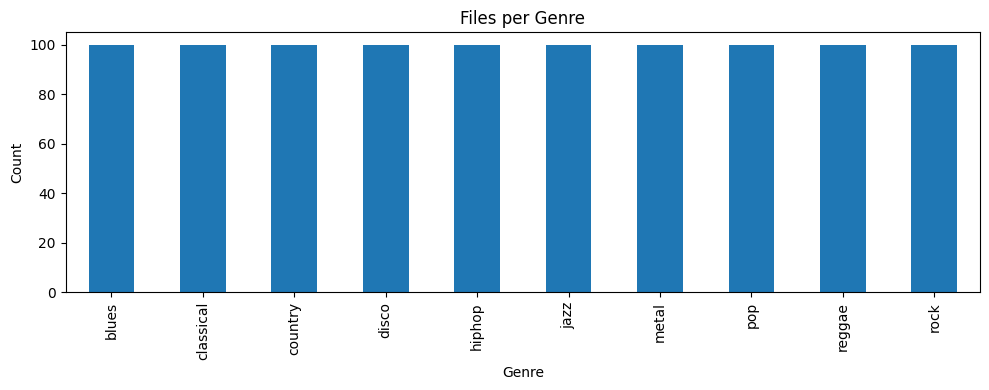

In [5]:
rows = []
for genre in GENRES:
    for f in (genres_dir / genre).glob('*.wav'):
        rows.append({'genre': genre, 'path': str(f)})

df = pd.DataFrame(rows)
print(df.shape)
display(df.head())

df['genre'].value_counts().sort_index().plot(
    kind='bar', figsize=(10, 4), title='Files per Genre')
plt.xlabel('Genre'); plt.ylabel('Count'); plt.tight_layout(); plt.show()

## 5. Audio Utility Functions

In [6]:
def safe_load_audio(path, sr=SR):
    """Load an audio file as mono float32; return None if unreadable."""
    try:
        y, _ = librosa.load(path, sr=sr, mono=True)
        return y.astype(np.float32)
    except Exception as e:
        print(f'Skipping unreadable file: {path} | {e}')
        return None


def fix_length_or_trim(y, target_len):
    if len(y) < target_len:
        return np.pad(y, (0, target_len - len(y)))
    return y[:target_len]


def split_audio_into_segments(y, segment_samples=SAMPLES_PER_SEGMENT):
    n = len(y) // segment_samples
    return [y[i * segment_samples:(i + 1) * segment_samples] for i in range(n)]


def mel_spectrogram(y, sr=SR):
    S = librosa.feature.melspectrogram(
        y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)
    S_db = librosa.power_to_db(S, ref=np.max)
    S_norm = (S_db - S_db.mean()) / (S_db.std() + 1e-8)
    return fix_time(S_norm).astype(np.float32)          # (N_MELS, MEL_FRAMES)


def mfcc_sequence(y, sr=SR):
    M = librosa.feature.mfcc(
        y=y, sr=sr, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH)
    M = (M - M.mean()) / (M.std() + 1e-8)
    return fix_time(M).T.astype(np.float32)             # (MEL_FRAMES, N_MFCC)


def fix_time(feat, frames=MEL_FRAMES):
    """Pad/trim the time axis (last axis) to a fixed number of frames."""
    if feat.shape[-1] < frames:
        return np.pad(feat, [(0, 0), (0, frames - feat.shape[-1])])
    return feat[:, :frames]

## 6. Precompute & Cache All Features (the key optimization)

Each 30s song is split into 3s segments. We load every file **once**, compute both the
mel spectrogram and MFCC features for each segment, and stack them into arrays that we
cache to a single `.npz`. Subsequent runs skip all audio decoding and feature compute.

We keep the original **file index** with every segment so we can split by file (not by
segment) and avoid train/test leakage.

In [7]:
def build_feature_cache():
    X_mel, X_mfcc, labels, file_idx = [], [], [], []
    for fi, row in df.iterrows():
        y = safe_load_audio(row['path'])
        if y is None:
            continue
        y = fix_length_or_trim(y, SR * DURATION)
        for seg in split_audio_into_segments(y):
            X_mel.append(mel_spectrogram(seg)[..., np.newaxis])  # (N_MELS, MEL_FRAMES, 1)
            X_mfcc.append(mfcc_sequence(seg))                    # (MEL_FRAMES, N_MFCC)
            labels.append(label_to_idx[row['genre']])
            file_idx.append(fi)
        if fi % 100 == 0:
            print(f'  processed {fi}/{len(df)} files')
    return (np.asarray(X_mel, np.float32), np.asarray(X_mfcc, np.float32),
            np.asarray(labels, np.int32), np.asarray(file_idx, np.int32))


if CACHE_FILE.exists():
    print('Loading cached features from', CACHE_FILE)
    cache = np.load(CACHE_FILE)
    X_mel, X_mfcc, y_all, file_idx = (
        cache['X_mel'], cache['X_mfcc'], cache['labels'], cache['file_idx'])
else:
    print('Computing features (one pass over the dataset)...')
    X_mel, X_mfcc, y_all, file_idx = build_feature_cache()
    np.savez_compressed(CACHE_FILE, X_mel=X_mel, X_mfcc=X_mfcc,
                        labels=y_all, file_idx=file_idx)
    print('Saved cache to', CACHE_FILE)

print('X_mel :', X_mel.shape)
print('X_mfcc:', X_mfcc.shape)
print('labels:', y_all.shape)

Computing features (one pass over the dataset)...
  processed 0/1000 files
  processed 100/1000 files
  processed 200/1000 files
  processed 300/1000 files
  processed 400/1000 files
  processed 500/1000 files
Skipping unreadable file: /kaggle/input/gtzan-dataset-music-genre-classification/Data/genres_original/jazz/jazz.00054.wav | 
  processed 600/1000 files
  processed 700/1000 files
  processed 800/1000 files
  processed 900/1000 files
Saved cache to /content/music_genre_project/features/gtzan_features.npz
X_mel : (9990, 128, 130, 1)
X_mfcc: (9990, 130, 40)
labels: (9990,)


## 7. File-Level Train / Validation / Test Split

We split by the **original file index** so segments from one song never appear in two
splits.

In [8]:
file_ids = np.unique(file_idx)
file_genres = df.loc[file_ids, 'genre'].values

train_f, temp_f = train_test_split(
    file_ids, test_size=0.30, random_state=SEED, stratify=file_genres)
temp_genres = df.loc[temp_f, 'genre'].values
val_f, test_f = train_test_split(
    temp_f, test_size=0.50, random_state=SEED, stratify=temp_genres)

train_f, val_f, test_f = set(train_f), set(val_f), set(test_f)
split = np.array(['train' if i in train_f else 'val' if i in val_f else 'test'
                  for i in file_idx])
for s in ('train', 'val', 'test'):
    print(f'{s:5s}: {(split == s).sum()} segments')

train: 6990 segments
val  : 1500 segments
test : 1500 segments


## 8. Build `tf.data` Pipelines (cached + GPU-side augmentation)

In [9]:
AUTOTUNE = tf.data.AUTOTUNE

def spec_augment(x, n_masks=2, freq_mask=12, time_mask=12, noise=0.05):
    """Cheap on-GPU augmentation for spectrogram/MFCC-style 2D features."""
    x = x + tf.random.normal(tf.shape(x), stddev=noise)
    h = tf.shape(x)[0]; w = tf.shape(x)[1]
    for _ in range(n_masks):
        f = tf.random.uniform([], 0, freq_mask, tf.int32)
        f0 = tf.random.uniform([], 0, tf.maximum(1, h - f), tf.int32)
        fm = tf.concat([tf.ones([f0, w]), tf.zeros([f, w]),
                        tf.ones([h - f0 - f, w])], 0)
        t = tf.random.uniform([], 0, time_mask, tf.int32)
        t0 = tf.random.uniform([], 0, tf.maximum(1, w - t), tf.int32)
        tm = tf.concat([tf.ones([h, t0]), tf.zeros([h, t]),
                        tf.ones([h, w - t0 - t])], 1)
        x = x * tf.expand_dims(fm * tm, -1) if x.shape.rank == 3 else x * (fm * tm)
    return x


def make_ds(X, y, mask, training=False, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((X[mask], y[mask]))
    ds = ds.cache()
    if training:
        ds = ds.shuffle(min(2048, mask.sum()), seed=SEED, reshuffle_each_iteration=True)
    if augment:
        ds = ds.map(lambda a, b: (spec_augment(a), b), num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)


tr = split == 'train'; va = split == 'val'; te = split == 'test'

mel_train_ds = make_ds(X_mel, y_all, tr, training=True, augment=True)
mel_val_ds   = make_ds(X_mel, y_all, va)
mel_test_ds  = make_ds(X_mel, y_all, te)

mfcc_train_ds = make_ds(X_mfcc, y_all, tr, training=True, augment=True)
mfcc_val_ds   = make_ds(X_mfcc, y_all, va)
mfcc_test_ds  = make_ds(X_mfcc, y_all, te)

## 9. Class Weights

In [10]:
classes = np.array(sorted(np.unique(y_all[tr])))
weights = compute_class_weight('balanced', classes=classes, y=y_all[tr])
class_weight = {int(c): float(w) for c, w in zip(classes, weights)}
print(class_weight)

{0: 0.9985714285714286, 1: 0.9985714285714286, 2: 0.9985714285714286, 3: 0.9985714285714286, 4: 0.9985714285714286, 5: 1.0130434782608695, 6: 0.9985714285714286, 7: 0.9985714285714286, 8: 0.9985714285714286, 9: 0.9985714285714286}


## 10. Visualize One Mel Spectrogram

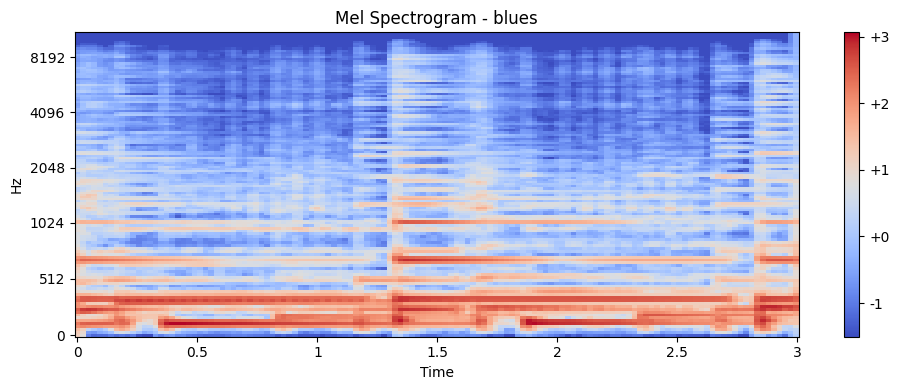

In [11]:
i = np.argmax(tr)
plt.figure(figsize=(10, 4))
librosa.display.specshow(X_mel[i, :, :, 0], sr=SR, hop_length=HOP_LENGTH,
                         x_axis='time', y_axis='mel')
plt.title(f'Mel Spectrogram - {idx_to_label[int(y_all[i])]}')
plt.colorbar(format='%+2.0f'); plt.tight_layout(); plt.show()

## 11. Training Helpers

In [12]:
def get_callbacks(name):
    return [
        keras.callbacks.ModelCheckpoint(
            str(MODEL_DIR / f'{name}.keras'), monitor='val_accuracy',
            save_best_only=True, mode='max', verbose=1),
        keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=8, restore_best_weights=True, mode='max'),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ]


def plot_history(history, title):
    hist = pd.DataFrame(history.history)
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    hist[['accuracy', 'val_accuracy']].plot(ax=ax[0], title=f'{title} Accuracy')
    hist[['loss', 'val_loss']].plot(ax=ax[1], title=f'{title} Loss')
    plt.tight_layout(); plt.show()


def evaluate_model(model, ds, title):
    y_true = np.concatenate([y.numpy() for _, y in ds])
    y_pred = np.argmax(model.predict(ds, verbose=0), axis=1)
    print(title)
    print(classification_report(y_true, y_pred, target_names=GENRES))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    plt.imshow(cm); plt.title(f'{title} Confusion Matrix'); plt.colorbar()
    plt.xticks(range(NUM_CLASSES), GENRES, rotation=45, ha='right')
    plt.yticks(range(NUM_CLASSES), GENRES)
    for r in range(NUM_CLASSES):
        for c in range(NUM_CLASSES):
            plt.text(c, r, cm[r, c], ha='center', va='center')
    plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.tight_layout(); plt.show()
    return classification_report(y_true, y_pred, target_names=GENRES, output_dict=True)

## 12. Model 1: CNN on Mel Spectrograms

In [13]:
def build_cnn_mel(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)
    x = inputs
    for filters, drop in [(32, 0.15), (64, 0.20), (128, 0.25)]:
        x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D()(x)
        x = layers.Dropout(drop)(x)
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.40)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = keras.Model(inputs, outputs, name='CNN_MelSpectrogram')
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

cnn_mel = build_cnn_mel(X_mel.shape[1:], NUM_CLASSES)
cnn_mel.summary()

Model: "CNN_MelSpectrogram"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 130, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 130, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 130, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 65, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 65, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 65, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 65, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 458,122 (1.75 MB)

 Trainable params: 457,162 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5579 - loss: 1.3221
Epoch 1: val_accuracy improved from None to 0.10000, saving model to /content/music_genre_project/models/cnn_mel_best.keras

Epoch 1: finished saving model to /content/music_genre_project/models/cnn_mel_best.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 28s 67ms/step - accuracy: 0.5642 - loss: 1.3284 - val_accuracy: 0.1000 - val_loss: 12.7856 - learning_rate: 0.0010
Epoch 2/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5871 - loss: 1.2349
Epoch 2: val_accuracy improved from 0.10000 to 0.31267, saving model to /content/music_genre_project/models/cnn_mel_best.keras

Epoch 2: finished saving model to /content/music_genre_project/models/cnn_mel_best.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.6412 - loss: 1.0785 - val_accuracy: 0.3127 - val_loss: 3.4760 - learning_rate: 0.0010
Epoch 3/40
217/219 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6442 - loss: 1.0541
Epoch 3: val_accuracy 

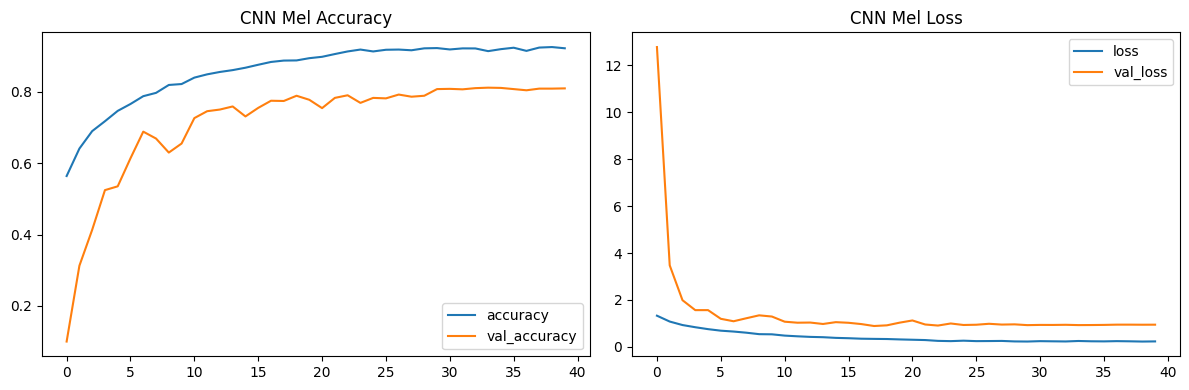

In [14]:
history_cnn = cnn_mel.fit(mel_train_ds, validation_data=mel_val_ds,
                          epochs=EPOCHS, class_weight=class_weight,
                          callbacks=get_callbacks('cnn_mel_best'))
plot_history(history_cnn, 'CNN Mel')

## 13. Model 2: CNN + BiLSTM on MFCC Sequences

In [15]:
def build_cnn_bilstm(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)
    x = inputs
    for filters, drop in [(64, 0.20), (128, 0.25)]:
        x = layers.Conv1D(filters, 5, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling1D(2)(x)
        x = layers.Dropout(drop)(x)
    x = layers.Bidirectional(layers.LSTM(96, return_sequences=True))(x)
    x = layers.Bidirectional(layers.LSTM(64))(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.40)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = keras.Model(inputs, outputs, name='CNN_BiLSTM_MFCC')
    model.compile(optimizer=keras.optimizers.Adam(8e-4),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

cnn_bilstm = build_cnn_bilstm(X_mfcc.shape[1:], NUM_CLASSES)
cnn_bilstm.summary()

Model: "CNN_BiLSTM_MFCC"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 130, 40)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 130, 64)        │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 130, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 65, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 65, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 65, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 65, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 32, 192)        │       172,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 376,906 (1.44 MB)

 Trainable params: 376,522 (1.44 MB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4432 - loss: 1.6375
Epoch 1: val_accuracy improved from None to 0.40733, saving model to /content/music_genre_project/models/cnn_bilstm_mfcc_best.keras

Epoch 1: finished saving model to /content/music_genre_project/models/cnn_bilstm_mfcc_best.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 16s 30ms/step - accuracy: 0.4654 - loss: 1.6131 - val_accuracy: 0.4073 - val_loss: 1.8332 - learning_rate: 8.0000e-04
Epoch 2/40
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4587 - loss: 1.5350
Epoch 2: val_accuracy improved from 0.40733 to 0.41667, saving model to /content/music_genre_project/models/cnn_bilstm_mfcc_best.keras

Epoch 2: finished saving model to /content/music_genre_project/models/cnn_bilstm_mfcc_best.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.5186 - loss: 1.4128 - val_accuracy: 0.4167 - val_loss: 1.7786 - learning_rate: 8.0000e-04
Epoch 3/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.487

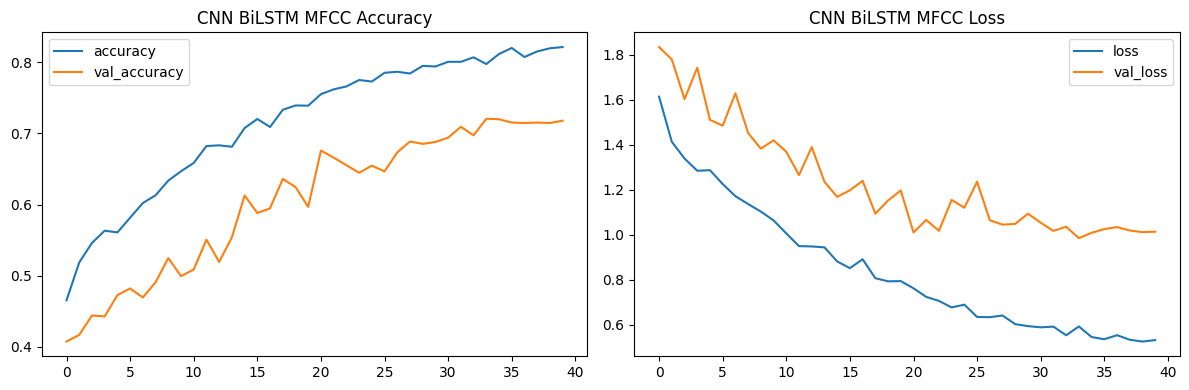

In [17]:
history_lstm = cnn_bilstm.fit(mfcc_train_ds, validation_data=mfcc_val_ds,
                              epochs=EPOCHS, class_weight=class_weight,
                              callbacks=get_callbacks('cnn_bilstm_mfcc_best'))
plot_history(history_lstm, 'CNN BiLSTM MFCC')

## 14. Model 3: Transfer Learning with EfficientNetB0

The cached single-channel mel features are resized to 224×224×3 **inside the `tf.data`
pipeline** (vectorised `tf.image.resize`), so we never materialise a 1.8 GB resized
array or call librosa per sample.

In [18]:
def to_efficientnet(x):
    x = tf.image.resize(x, (224, 224))      # (224, 224, 1)
    return tf.repeat(x, 3, axis=-1)         # (224, 224, 3)

def make_transfer_ds(mask, training=False):
    ds = tf.data.Dataset.from_tensor_slices((X_mel[mask], y_all[mask]))
    if training:
        ds = ds.shuffle(min(2048, mask.sum()), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(lambda a, b: (to_efficientnet(a), b), num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

transfer_train_ds = make_transfer_ds(tr, training=True)
transfer_val_ds   = make_transfer_ds(va)
transfer_test_ds  = make_transfer_ds(te)

def build_efficientnet(num_classes):
    inputs = keras.Input(shape=(224, 224, 3))
    base = keras.applications.EfficientNetB0(
        include_top=False, weights='imagenet', input_tensor=inputs)
    base.trainable = False
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dropout(0.35)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.35)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = keras.Model(inputs, outputs, name='EfficientNetB0_Spectrogram')
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model, base

effnet, eff_base = build_efficientnet(NUM_CLASSES)
effnet.summary()

Model: "EfficientNetB0_Spectrogram"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_3[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,380,077 (16.71 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.0620 - loss: 2.2584
Epoch 1: val_accuracy improved from None to 0.19800, saving model to /content/music_genre_project/models/efficientnet_frozen_best.keras

Epoch 1: finished saving model to /content/music_genre_project/models/efficientnet_frozen_best.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 14s 60ms/step - accuracy: 0.1702 - loss: 2.1058 - val_accuracy: 0.1980 - val_loss: 1.9957 - learning_rate: 2.5000e-04
Epoch 2/40
217/219 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.0614 - loss: 2.2007
Epoch 2: val_accuracy improved from 0.19800 to 0.20067, saving model to /content/music_genre_project/models/efficientnet_frozen_best.keras

Epoch 2: finished saving model to /content/music_genre_project/models/efficientnet_frozen_best.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - accuracy: 0.1680 - loss: 2.0809 - val_accuracy: 0.2007 - val_loss: 1.9780 - learning_rate: 2.5000e-04
Epoch 3/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step 

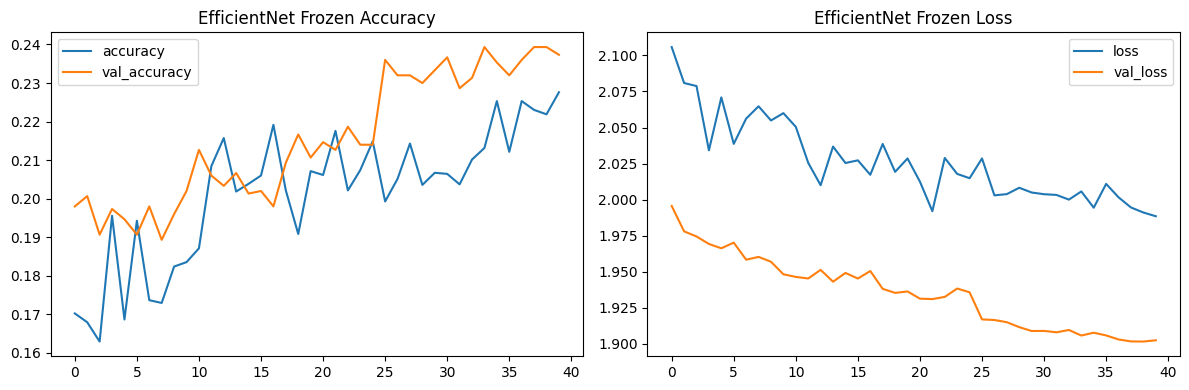

In [20]:
history_eff = effnet.fit(transfer_train_ds, validation_data=transfer_val_ds,
                         epochs=40, class_weight=class_weight,
                         callbacks=get_callbacks('efficientnet_frozen_best'))
plot_history(history_eff, 'EfficientNet Frozen')

### Optional Fine-Tuning (unfreeze top of EfficientNet)

Epoch 1/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.2268 - loss: 2.4563
Epoch 1: val_accuracy improved from None to 0.19600, saving model to /content/music_genre_project/models/efficientnet_finetuned_best.keras

Epoch 1: finished saving model to /content/music_genre_project/models/efficientnet_finetuned_best.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 70s 181ms/step - accuracy: 0.1927 - loss: 2.8554 - val_accuracy: 0.1960 - val_loss: 2.0439 - learning_rate: 1.0000e-05
Epoch 2/15
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.1699 - loss: 2.2280
Epoch 2: val_accuracy improved from 0.19600 to 0.25133, saving model to /content/music_genre_project/models/efficientnet_finetuned_best.keras

Epoch 2: finished saving model to /content/music_genre_project/models/efficientnet_finetuned_best.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 13s 61ms/step - accuracy: 0.2041 - loss: 2.1756 - val_accuracy: 0.2513 - val_loss: 1.9546 - learning_rate: 1.0000e-05
Epoch 3/15
218/219 ━━━━━━━━━━━━━━━━━━━━

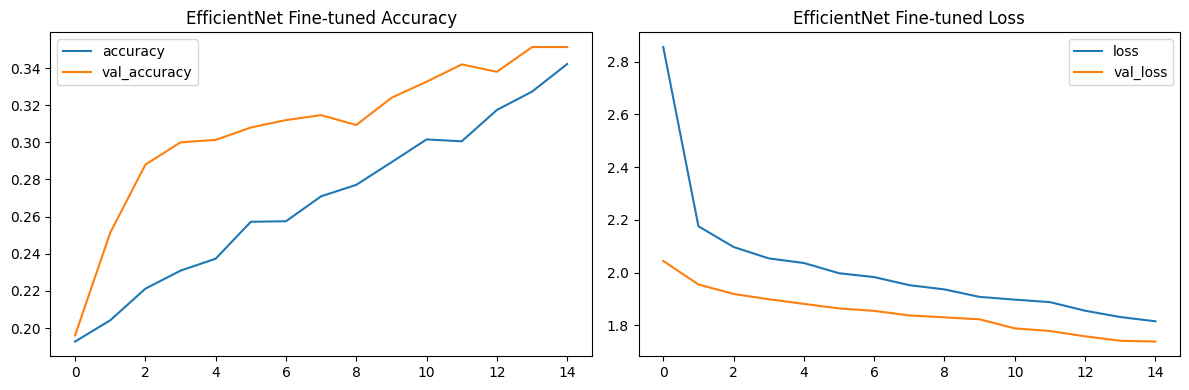

In [21]:
eff_base.trainable = True
for layer in eff_base.layers[:-30]:
    layer.trainable = False

effnet.compile(optimizer=keras.optimizers.Adam(1e-5),
               loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_eff_ft = effnet.fit(transfer_train_ds, validation_data=transfer_val_ds,
                            epochs=15, class_weight=class_weight,
                            callbacks=get_callbacks('efficientnet_finetuned_best'))
plot_history(history_eff_ft, 'EfficientNet Fine-tuned')

## 15. Evaluate All Models on the Test Set

CNN Mel Test
              precision    recall  f1-score   support

       blues       0.84      0.91      0.87       150
   classical       0.75      0.96      0.84       150
     country       0.79      0.70      0.74       150
       disco       0.85      0.93      0.89       150
      hiphop       0.84      0.80      0.82       150
        jazz       0.86      0.71      0.78       150
       metal       0.95      0.93      0.94       150
         pop       0.84      0.75      0.79       150
      reggae       0.79      0.82      0.81       150
        rock       0.68      0.67      0.68       150

    accuracy                           0.82      1500
   macro avg       0.82      0.82      0.82      1500
weighted avg       0.82      0.82      0.82      1500



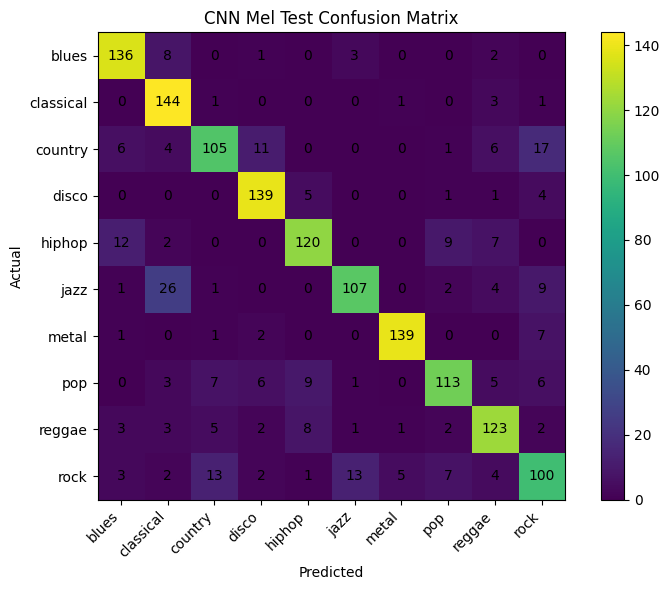

CNN BiLSTM MFCC Test
              precision    recall  f1-score   support

       blues       0.81      0.79      0.80       150
   classical       0.81      0.93      0.86       150
     country       0.71      0.61      0.65       150
       disco       0.75      0.78      0.77       150
      hiphop       0.73      0.49      0.59       150
        jazz       0.63      0.60      0.62       150
       metal       0.77      0.77      0.77       150
         pop       0.69      0.78      0.73       150
      reggae       0.67      0.87      0.75       150
        rock       0.52      0.49      0.50       150

    accuracy                           0.71      1500
   macro avg       0.71      0.71      0.70      1500
weighted avg       0.71      0.71      0.70      1500



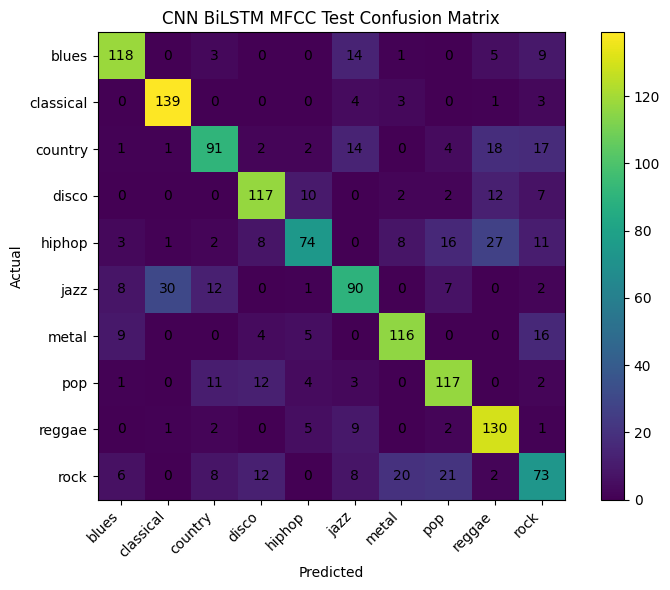

EfficientNet Spectrogram Test
              precision    recall  f1-score   support

       blues       0.64      0.06      0.11       150
   classical       0.71      0.45      0.55       150
     country       0.26      0.03      0.06       150
       disco       0.25      0.09      0.13       150
      hiphop       0.44      0.49      0.47       150
        jazz       0.58      0.49      0.53       150
       metal       0.62      0.79      0.69       150
         pop       0.49      0.45      0.47       150
      reggae       0.33      0.64      0.43       150
        rock       0.14      0.39      0.21       150

    accuracy                           0.39      1500
   macro avg       0.45      0.39      0.37      1500
weighted avg       0.45      0.39      0.37      1500



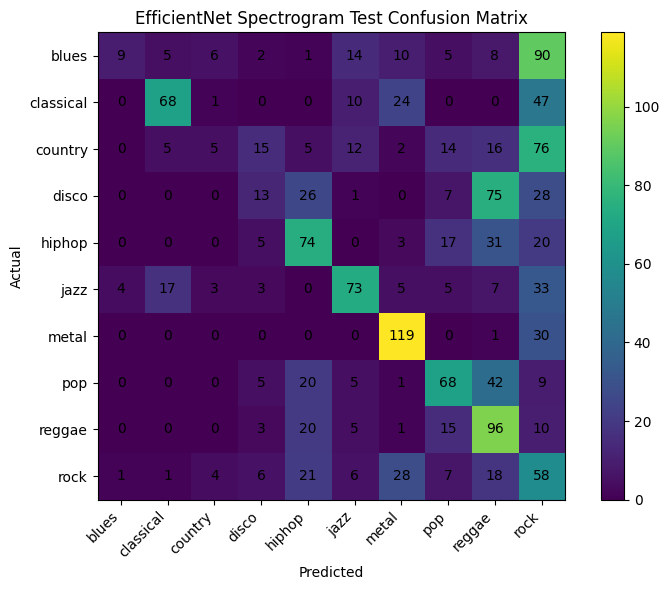

,model,accuracy,macro_f1,weighted_f1
0,CNN Mel,0.817333,0.815583,0.815583
1,CNN BiLSTM MFCC,0.710000,0.704849,0.704849
2,EfficientNet Spectrogram,0.388667,0.365541,0.365541


In [22]:
reports = {}

best_cnn = keras.models.load_model(MODEL_DIR / 'cnn_mel_best.keras')
reports['CNN Mel'] = evaluate_model(best_cnn, mel_test_ds, 'CNN Mel Test')

best_lstm = keras.models.load_model(MODEL_DIR / 'cnn_bilstm_mfcc_best.keras')
reports['CNN BiLSTM MFCC'] = evaluate_model(best_lstm, mfcc_test_ds, 'CNN BiLSTM MFCC Test')

ft_path = MODEL_DIR / 'efficientnet_finetuned_best.keras'
frozen_path = MODEL_DIR / 'efficientnet_frozen_best.keras'
best_eff = keras.models.load_model(ft_path if ft_path.exists() else frozen_path)
reports['EfficientNet Spectrogram'] = evaluate_model(
    best_eff, transfer_test_ds, 'EfficientNet Spectrogram Test')

summary_df = pd.DataFrame([
    {'model': k, 'accuracy': r['accuracy'],
     'macro_f1': r['macro avg']['f1-score'],
     'weighted_f1': r['weighted avg']['f1-score']}
    for k, r in reports.items()
]).sort_values('accuracy', ascending=False).reset_index(drop=True)
display(summary_df)

## 16. Select and Save the Best Model (+ metadata for deployment)

In [23]:
best_model_name = summary_df.iloc[0]['model']
print('Best model:', best_model_name)

final_model, final_model_type = {
    'CNN Mel': (best_cnn, 'mel'),
    'CNN BiLSTM MFCC': (best_lstm, 'mfcc'),
    'EfficientNet Spectrogram': (best_eff, 'transfer'),
}[best_model_name]

final_model.save(MODEL_DIR / 'final_best_music_genre_model.keras')

metadata = {
    'genres': GENRES, 'label_to_idx': label_to_idx, 'idx_to_label': idx_to_label,
    'model_type': final_model_type, 'sr': SR, 'duration': DURATION,
    'segment_seconds': SEGMENT_SECONDS, 'n_mels': N_MELS, 'n_mfcc': N_MFCC,
    'hop_length': HOP_LENGTH, 'n_fft': N_FFT, 'mel_frames': MEL_FRAMES,
    'test_accuracy': float(summary_df.iloc[0]['accuracy']),
    'best_model_name': best_model_name,
}
with open(MODEL_DIR / 'metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print('Saved final model + metadata to', MODEL_DIR)

Best model: CNN Mel
Saved final model + metadata to /content/music_genre_project/models


## 17. Predict Genre for a New Uploaded Audio File

Predictions are averaged across all 3s segments of the uploaded clip.

In [24]:
from google.colab import files
uploaded = files.upload()
user_audio_path = list(uploaded.keys())[0]
print('Uploaded:', user_audio_path)

Saving 02 - Suno Ke Main Hun Jawan (Apniisp.Com).mp3 to 02 - Suno Ke Main Hun Jawan (Apniisp.Com).mp3
Uploaded: 02 - Suno Ke Main Hun Jawan (Apniisp.Com).mp3


Predicted Genre: country


,genre,probability
0,country,0.614605
1,rock,0.307337
2,disco,0.030766
3,classical,0.016549
4,hiphop,0.010193
5,pop,0.006867
6,metal,0.005639
7,blues,0.005614
8,reggae,0.001868
9,jazz,0.000561


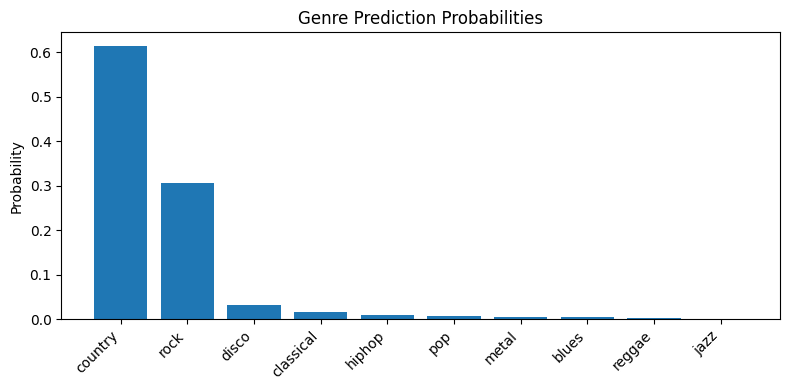

In [25]:
def featurize_segment(seg, model_type):
    if model_type == 'mfcc':
        return mfcc_sequence(seg)
    feat = mel_spectrogram(seg)[..., np.newaxis]
    if model_type == 'transfer':
        feat = tf.image.resize(feat, (224, 224)).numpy()
        feat = np.repeat(feat, 3, axis=-1)
    return feat


def predict_audio_file(audio_path, model, model_type='mel'):
    y = safe_load_audio(audio_path)
    if y is None:
        raise ValueError('Could not load audio file.')
    segments = split_audio_into_segments(y) or [fix_length_or_trim(y, SAMPLES_PER_SEGMENT)]
    batch = np.array([featurize_segment(s, model_type).astype(np.float32)
                      for s in segments])
    avg_probs = model.predict(batch, verbose=0).mean(axis=0)
    pred_genre = idx_to_label[int(np.argmax(avg_probs))]
    result = pd.DataFrame({'genre': GENRES, 'probability': avg_probs}) \
        .sort_values('probability', ascending=False).reset_index(drop=True)
    return pred_genre, result

pred_genre, result = predict_audio_file(user_audio_path, final_model, final_model_type)
print('Predicted Genre:', pred_genre)
display(result)
plt.figure(figsize=(8, 4))
plt.bar(result['genre'], result['probability'])
plt.title('Genre Prediction Probabilities'); plt.xticks(rotation=45, ha='right')
plt.ylabel('Probability'); plt.tight_layout(); plt.show()

## 18. Export the Hugging Face Space Bundle

This writes a ready-to-push Gradio Space (`app.py`, `requirements.txt`, `README.md`)
into `huggingface_space/`, copies in the best model + metadata, and zips everything for
download. Follow `DEPLOYMENT_GUIDE.md` to push it live.

In [26]:
APP_PY = r'''import os
import json
from pathlib import Path

import numpy as np
import librosa
import tensorflow as tf
import keras
import gradio as gr

# --- Version-tolerant model loading -----------------------------------------
# The model may be saved by a newer Keras than the one the Space installs. Newer
# Keras adds a `quantization_config` arg to some layers that older Keras rejects
# ("Unrecognized keyword arguments passed to Dense"). Its value is None (no
# quantization), so we strip it from every layer constructor before loading. This
# makes the app load the model on ANY Keras 3.x.
_orig_layer_init = keras.layers.Layer.__init__


def _tolerant_layer_init(self, *args, **kwargs):
    kwargs.pop("quantization_config", None)
    _orig_layer_init(self, *args, **kwargs)


keras.layers.Layer.__init__ = _tolerant_layer_init

META = json.loads(Path("metadata.json").read_text())
GENRES = META["genres"]
IDX2LABEL = {int(k): v for k, v in META["idx_to_label"].items()}
MODEL_TYPE = META["model_type"]
SR = META["sr"]
SAMPLES_PER_SEGMENT = SR * META["segment_seconds"]
N_FFT, HOP, N_MELS, N_MFCC = META["n_fft"], META["hop_length"], META["n_mels"], META["n_mfcc"]
MEL_FRAMES = META["mel_frames"]

# compile=False: inference only, so skip optimizer/loss deserialization.
model = keras.models.load_model("final_best_music_genre_model.keras", compile=False)


def fix_time(feat, frames=MEL_FRAMES):
    if feat.shape[-1] < frames:
        return np.pad(feat, [(0, 0), (0, frames - feat.shape[-1])])
    return feat[:, :frames]


def mel_spec(y):
    S = librosa.feature.melspectrogram(y=y, sr=SR, n_fft=N_FFT, hop_length=HOP, n_mels=N_MELS)
    S = librosa.power_to_db(S, ref=np.max)
    S = (S - S.mean()) / (S.std() + 1e-8)
    return fix_time(S).astype(np.float32)


def mfcc_seq(y):
    M = librosa.feature.mfcc(y=y, sr=SR, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP)
    M = (M - M.mean()) / (M.std() + 1e-8)
    return fix_time(M).T.astype(np.float32)


def featurize(seg):
    if MODEL_TYPE == "mfcc":
        return mfcc_seq(seg)
    feat = mel_spec(seg)[..., np.newaxis]
    if MODEL_TYPE == "transfer":
        feat = tf.image.resize(feat, (224, 224)).numpy()
        feat = np.repeat(feat, 3, axis=-1)
    return feat


def predict(audio):
    if audio is None:
        return {}
    sr, y = audio
    y = y.astype(np.float32)
    if y.ndim > 1:
        y = y.mean(axis=1)
    y = y / (np.max(np.abs(y)) + 1e-8)
    if sr != SR:
        y = librosa.resample(y, orig_sr=sr, target_sr=SR)
    n = len(y) // SAMPLES_PER_SEGMENT
    segs = [y[i * SAMPLES_PER_SEGMENT:(i + 1) * SAMPLES_PER_SEGMENT] for i in range(n)]
    if not segs:
        segs = [np.pad(y, (0, max(0, SAMPLES_PER_SEGMENT - len(y))))[:SAMPLES_PER_SEGMENT]]
    batch = np.array([featurize(s) for s in segs], dtype=np.float32)
    probs = model.predict(batch, verbose=0).mean(axis=0)
    return {IDX2LABEL[i]: float(probs[i]) for i in range(len(GENRES))}


demo = gr.Interface(
    fn=predict,
    inputs=gr.Audio(type="numpy", label="Upload a music clip"),
    outputs=gr.Label(num_top_classes=5, label="Predicted Genre"),
    title="Music Genre Classifier",
    description=f"Best model: {META.get('best_model_name', MODEL_TYPE)} "
                f"(test accuracy {META.get('test_accuracy', 0):.1%}). "
                "Upload an audio clip to predict its genre.",
)

if __name__ == "__main__":
    on_space = bool(os.environ.get("SPACE_ID"))
    demo.launch(share=not on_space)
'''

# Auto-pin to THIS notebook's training environment so the saved model deserializes
# on the Space. Do NOT pin gradio here (HF installs it from README sdk_version).
REQS = f"""# Auto-generated to match the training environment. tensorflow-cpu/keras must be
# >= the versions that saved the model; app.py also tolerates version drift.
tensorflow-cpu=={tf.__version__}
keras=={keras.__version__}
librosa==0.10.1
soundfile
numpy<2.0
"""

README = f"""---
title: Music Genre Classifier
emoji: 🎵
colorFrom: indigo
colorTo: purple
sdk: gradio
sdk_version: 6.19.0
python_version: "3.10"
app_file: app.py
pinned: false
license: mit
---

# Music Genre Classifier

Deep learning model that classifies music clips into {NUM_CLASSES} genres
({', '.join(GENRES)}), trained on the GTZAN dataset.

- **Best model:** {metadata['best_model_name']}
- **Test accuracy:** {metadata['test_accuracy']:.1%}

Upload a short audio clip and the model averages predictions across its 3-second
segments. Built from the optimized training notebook in this project.
"""

(SPACE_DIR / 'app.py').write_text(APP_PY)
(SPACE_DIR / 'requirements.txt').write_text(REQS)
(SPACE_DIR / 'README.md').write_text(README)
shutil.copy(MODEL_DIR / 'final_best_music_genre_model.keras', SPACE_DIR)
shutil.copy(MODEL_DIR / 'metadata.json', SPACE_DIR)

shutil.make_archive('/content/huggingface_space', 'zip', SPACE_DIR)
print('Space bundle ready. Download: /content/huggingface_space.zip')
print('Pinned versions -> tensorflow-cpu==%s, keras==%s' % (tf.__version__, keras.__version__))
print('Files:', sorted(p.name for p in SPACE_DIR.iterdir()))

Space bundle ready. Download: /content/huggingface_space.zip
Pinned versions -> tensorflow-cpu==2.20.0, keras==3.13.2
Files: ['README.md', 'app.py', 'final_best_music_genre_model.keras', 'metadata.json', 'requirements.txt']


## 19. Project Report Summary

### Objective
Classify music clips into genres using deep learning, then deploy the best model.

### Dataset
GTZAN — 10 genres, 100 clips each (30s).

### Pipeline
- 3-second segmentation; **features computed once and cached** to `.npz`.
- File-level train/val/test split to prevent leakage.
- `tf.data` with `.cache()`, shuffling, and GPU-side SpecAugment.
- Three models compared: CNN (mel), CNN+BiLSTM (MFCC), EfficientNetB0 (transfer).
- Early stopping, LR reduction, class weights.
- Best model exported with metadata and packaged as a Hugging Face Gradio Space.

### Efficiency notes
The dominant cost in the original notebook was redundant audio decoding and feature
recomputation inside `from_generator` (every segment reloaded the whole file, every
epoch). Caching features once and serving them with `tf.data.from_tensor_slices` +
`.cache()` removes that bottleneck and keeps the GPU fed.